# Loading and Formatting Data

In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Dataset Import

In [2]:
class KidneyStoneDetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        img_width, img_height = image.size
        
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(self.labels_dir, txt_name)
        
        boxes = []
        labels = []
        
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                        
                        w = w_norm * img_width
                        h = h_norm * img_height
                        x_min = (x_c * img_width) - (w / 2)
                        y_min = (y_c * img_height) - (h / 2)
                        x_max = x_min + w
                        y_max = y_min + h
                        
                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(1) 
        
        if len(boxes) == 0:
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        
        if self.transform:
            image = self.transform(image)
            
        return image, target

# Object detection models prefer basic tensor conversion without aggressive normalization
data_transforms = transforms.Compose([transforms.ToTensor()])

# We must define a custom collate function to handle variable numbers of bounding boxes per image
def collate_fn(batch):
    return tuple(zip(*batch))

base_dir = 'archive'

training_data = KidneyStoneDetectionDataset(
    images_dir=f'{base_dir}/train/images', 
    labels_dir=f'{base_dir}/train/labels', 
    transform=data_transforms
)

valid_data = KidneyStoneDetectionDataset(
    images_dir=f'{base_dir}/valid/images', 
    labels_dir=f'{base_dir}/valid/labels', 
    transform=data_transforms
)

# Batch size lowered to 4 or 8 to prevent memory crashes with Faster R-CNN
train_dataloader = DataLoader(training_data, batch_size=4, shuffle=True, collate_fn=collate_fn)
valid_dataloader = DataLoader(valid_data, batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f"Total training scans loaded: {len(training_data)}")

Total training scans loaded: 1054


# Simple CNN Architecture

# Region CNN Architecture

In [3]:
def get_kidney_stone_detector():
    # Load pre-trained Faster R-CNN with a ResNet-50 backbone
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the head: We need 2 classes -> Background (0) and Stone (1)
    num_classes = 2 
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# Initialize the model
model = get_kidney_stone_detector()

# Move model to GPU if available for faster training
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Model loaded and running on: {device}")

Model loaded and running on: cuda


# Training Loop

Epoch 1
-------------------------------
Batch 0: Loss = 2.6163
Batch 10: Loss = 0.4978
Batch 20: Loss = 0.2239
Batch 30: Loss = 0.2144
Batch 40: Loss = 0.6461
Batch 50: Loss = 0.2035
Batch 60: Loss = 0.4549
Batch 70: Loss = 0.3451
Batch 80: Loss = 0.2316
Batch 90: Loss = 0.2850
Batch 100: Loss = 0.1542
Batch 110: Loss = 0.1348
Batch 120: Loss = 0.2531
Batch 130: Loss = 0.2070
Batch 140: Loss = 0.4991
Batch 150: Loss = 0.5146
Batch 160: Loss = 0.3917
Batch 170: Loss = 0.3799
Batch 180: Loss = 0.2874
Batch 190: Loss = 0.1867
Batch 200: Loss = 0.4704
Batch 210: Loss = 0.2154
Batch 220: Loss = 0.1728
Batch 230: Loss = 0.3938
Batch 240: Loss = 0.1909
Batch 250: Loss = 0.1440
Batch 260: Loss = 0.1655
End of Epoch 1 | Average Loss: 0.2902

Epoch 2
-------------------------------
Batch 0: Loss = 0.1939
Batch 10: Loss = 0.1183
Batch 20: Loss = 0.1226
Batch 30: Loss = 0.2376
Batch 40: Loss = 0.0807
Batch 50: Loss = 0.1277
Batch 60: Loss = 0.3211
Batch 70: Loss = 0.3610
Batch 80: Loss = 0.3129
Ba

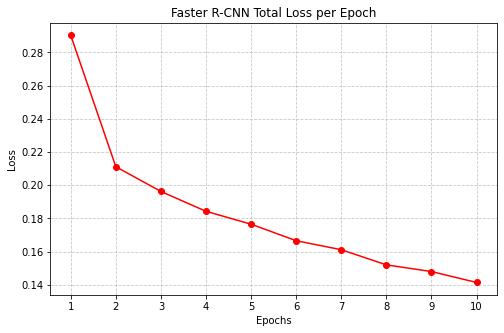

In [4]:
# We use standard Stochastic Gradient Descent for Faster R-CNN
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

epochs = 10 # Faster R-CNN takes longer per epoch, 5 is a good starting point
train_losses = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    model.train() # Crucial: Faster R-CNN only calculates loss when in train() mode
    epoch_loss = 0
    
    for batch_idx, (images, targets) in enumerate(train_dataloader):
        # Move images and targets to GPU/CPU
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # The model automatically computes the loss dictionary when in training mode
        loss_dict = model(images, targets)
        
        # Combine the different types of losses (classification, box tightness, etc.)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        
        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}: Loss = {losses.item():.4f}")
            
    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    print(f"End of Epoch {epoch+1} | Average Loss: {avg_loss:.4f}\n")

# Plot the total loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='red')
plt.title('Faster R-CNN Total Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Inference Mode

Starting batch validation on 5 random CT scans...

========== DIAGNOSTIC REPORT: SCAN 1 ==========
Ground Truth (Actual Calculi): 2
Model Detections: 1

Stone 1 [FALSE POSITIVE]: Conf=98.2% | W=11.2px, H=11.9px


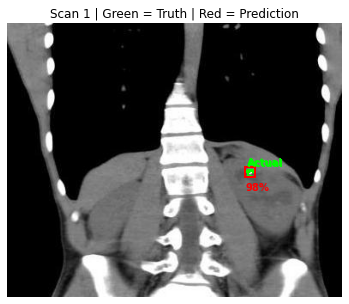



========== DIAGNOSTIC REPORT: SCAN 2 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 1

Stone 1 [CORRECT]: Conf=98.7% | W=8.7px, H=7.8px


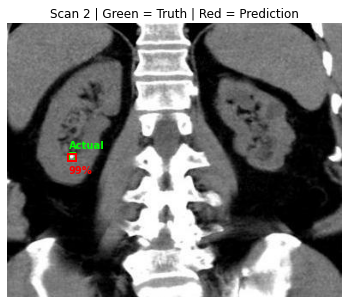



========== DIAGNOSTIC REPORT: SCAN 3 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 1

Stone 1 [CORRECT]: Conf=98.1% | W=8.6px, H=6.8px


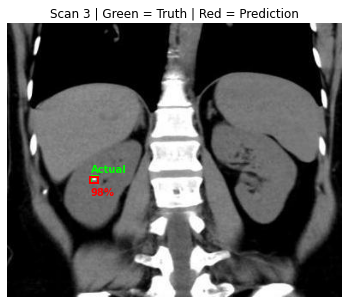



========== DIAGNOSTIC REPORT: SCAN 4 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 1

Stone 1 [CORRECT]: Conf=98.5% | W=26.2px, H=23.0px


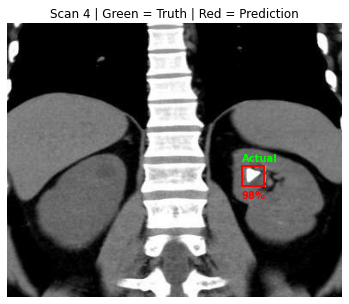



========== DIAGNOSTIC REPORT: SCAN 5 ==========
Ground Truth (Actual Calculi): 2
Model Detections: 2

Stone 1 [CORRECT]: Conf=98.5% | W=10.1px, H=8.5px
Stone 2 [CORRECT]: Conf=97.9% | W=7.6px, H=6.4px


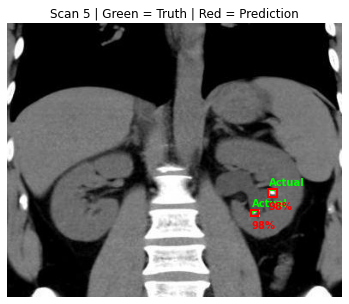

In [15]:
import torch
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import box_iou, nms

# ---------------------------------------------------------
# SETUP BATCH VALIDATION
# ---------------------------------------------------------
model.eval()
num_samples_to_test = 5 

# Pick random indices from your validation dataset
total_valid_scans = len(valid_data)
# min() ensures it won't crash if you ask for 10 but only have 8 validation scans
sample_indices = random.sample(range(total_valid_scans), min(num_samples_to_test, total_valid_scans))

print(f"Starting batch validation on {len(sample_indices)} random CT scans...\n")

for batch_num, sample_index in enumerate(sample_indices):
    print(f"========== DIAGNOSTIC REPORT: SCAN {batch_num + 1} ==========")
    
    # ---------------------------------------------------------
    # 1. INFERENCE & FILTERING
    # ---------------------------------------------------------
    image_tensor, true_target = valid_data[sample_index]

    with torch.no_grad():
        prediction = model([image_tensor.to(device)])

    raw_boxes = prediction[0]['boxes'].cpu()
    raw_scores = prediction[0]['scores'].cpu()
    true_boxes = true_target['boxes'].cpu()

    # Apply Confidence Filter
    conf_threshold = 0.5
    high_conf_mask = raw_scores > conf_threshold
    conf_boxes = raw_boxes[high_conf_mask]
    conf_scores = raw_scores[high_conf_mask]

    # Apply Non-Maximum Suppression (NMS) 
    nms_threshold = 0.3
    keep_indices = nms(conf_boxes, conf_scores, nms_threshold)
    valid_boxes = conf_boxes[keep_indices]
    valid_scores = conf_scores[keep_indices]

    # ---------------------------------------------------------
    # 2. ACCURACY EVALUATION
    # ---------------------------------------------------------
    num_true = len(true_boxes)
    num_pred = len(valid_boxes)

    print(f"Ground Truth (Actual Calculi): {num_true}")
    print(f"Model Detections: {num_pred}\n")

    if num_true > 0 and num_pred > 0:
        ious = box_iou(valid_boxes, true_boxes)
        for i, box in enumerate(valid_boxes):
            x_min, y_min, x_max, y_max = box
            width, height = x_max - x_min, y_max - y_min
            conf = valid_scores[i].item() * 100
            
            best_iou = ious[i].max().item()
            status = "CORRECT" if best_iou > 0.5 else "FALSE POSITIVE"
            
            print(f"Stone {i+1} [{status}]: Conf={conf:.1f}% | W={width.item():.1f}px, H={height.item():.1f}px")
            
    elif num_pred > 0 and num_true == 0:
        print("Result: False Positives detected on a healthy scan.")
    elif num_pred == 0 and num_true > 0:
        print("Result: False Negatives. Model missed the calculi.")
    else:
        print("Result: Correctly identified healthy scan (True Negative).")

    # ---------------------------------------------------------
    # 3. VISUALIZATION
    # ---------------------------------------------------------
    image_to_plot = image_tensor.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(6, 6)) # Slightly smaller to fit multiple in output
    ax.imshow(image_to_plot)

    # Draw GROUND TRUTH (Green Dashed)
    for box in true_boxes:
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                 linewidth=2, edgecolor='lime', linestyle='--', facecolor='none')
        ax.add_patch(rect)
        plt.text(x_min, y_min - 5, 'Actual', color='lime', weight='bold')

    # Draw PREDICTIONS (Red Solid)
    for i, box in enumerate(valid_boxes):
        x_min, y_min, x_max, y_max = box
        conf = valid_scores[i].item() * 100
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        plt.text(x_min, y_max + 15, f'{conf:.0f}%', color='red', weight='bold')

    plt.axis('off')
    plt.title(f"Scan {batch_num + 1} | Green = Truth | Red = Prediction")
    plt.show()
    print("\n" + "="*50 + "\n") # Visual separator between scans

# Demonstration of Dataset Format

Scanning 3 random files...



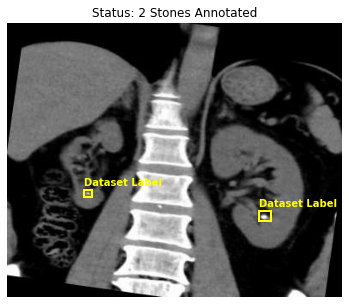

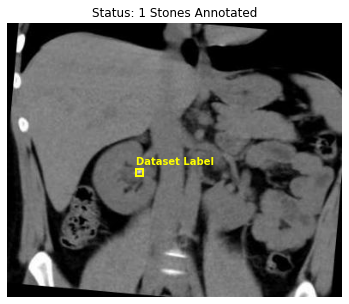

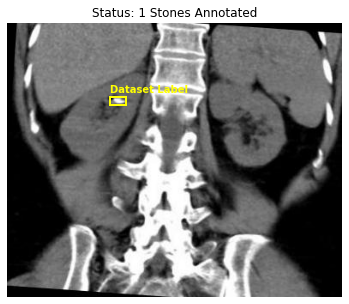

In [14]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def automated_dataset_check(images_dir, labels_dir, num_samples=3):
    """
    Randomly selects and visualizes a set number of images and their YOLO bounding boxes.
    """
    # 1. Grab every image file in the folder
    all_images = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    if not all_images:
        print(f"No images found in {images_dir}")
        return

    # 2. Pick a random subset to check
    # (Uses min() just in case you ask for 5 samples but only have 3 images left)
    random_samples = random.sample(all_images, min(num_samples, len(all_images)))
    
    print(f"Scanning {len(random_samples)} random files...\n")
    
    # 3. Loop through the randomly selected images
    for img_name in random_samples:
        img_path = os.path.join(images_dir, img_name)
        
        # Construct the matching label path automatically
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(labels_dir, txt_name)
        
        # Load the image
        img = Image.open(img_path).convert('RGB')
        img_width, img_height = img.size
        
        # Setup plotting
        fig, ax = plt.subplots(1, figsize=(6, 6))
        ax.imshow(img)
        
        stones_found = 0
        
        # Read the label file if it exists and isn't empty
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        stones_found += 1
                        x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                        
                        w = w_norm * img_width
                        h = h_norm * img_height
                        x_min = (x_c * img_width) - (w / 2)
                        y_min = (y_c * img_height) - (h / 2)
                        
                        rect = patches.Rectangle((x_min, y_min), w, h, 
                                                 linewidth=2, edgecolor='yellow', facecolor='none')
                        ax.add_patch(rect)
                        plt.text(x_min, y_min - 5, 'Dataset Label', color='yellow', fontsize=10, weight='bold')

        plt.axis('off')
        
        # Give each plot a clean title showing its status
        if stones_found > 0:
            plt.title(f"Status: {stones_found} Stones Annotated")
        else:
            plt.title("Status: Healthy Scan (No Annotations)")
            
        plt.show()

# --- Automated Usage ---
# Ensure base_dir matches the path you defined in Cell 1/2
base_dir = 'archive'

# Change 'num_samples' to output as many random scans as you want to verify at once
automated_dataset_check(
    images_dir=f'{base_dir}/train/images', 
    labels_dir=f'{base_dir}/train/labels', 
    num_samples=3 
)